# Geant4 Simualtion Analysis
### EJ-232 Scintillator: Photon Arrival Time Analysis

Daten mit 1000 Events

Daten die aufgenommen wurden:
EventID
Hit: Top oder Bottom
GlobalTime
TimeSinceZero
TrackLenght
PhotonEnergy
PhotonFlightTime
Process: Welcher Prozess

In [238]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
_original_plt_show = plt.show
_saved_plot_names = {}


def _show_and_save_plot(*args, **kwargs):
    figure = plt.gcf()
    title = figure.axes[0].get_title() if figure.axes else "plot"
    filename = re.sub(r"[^a-zA-Z0-9_-]+", "_", title).strip("_").lower()
    filename = filename or "plot"

    plot_number = _saved_plot_names.get(filename, 0) + 1
    _saved_plot_names[filename] = plot_number
    suffix = "" if plot_number == 1 else f"_{plot_number}"
    figure.savefig(
        PLOTS_DIR / f"{filename}{suffix}.png",
        dpi=300,
        bbox_inches="tight"
    )
    _original_plt_show(*args, **kwargs)


plt.show = _show_and_save_plot

### Daten

In [204]:
CSV_PATH = "data2.csv"

COLUMN_NAMES = [
    "RunID",
    "EventID",
    "TrackID",
    "Hit",
    "GlobalTime",
    "TimeSinceZero",
    "TrackLenght",
    "PhotonEnergy",
    "PhotonFlightTime",
    "PhotonCreationTime",
    "Process"
]

DTYPES = {
    "RunID": "int32",
    "EventID": "int32",
    "trackID": "int32",
    "hit": "category",
    "globaltime": "float64",
    "timesinceelectronhit": "float64",
    "trackLength": "float32",
    "photonEnergy": "float32",
    "photonFlightTime": "float32",
    "photonCreationTime": "float32",
    "creatorProcess": "category",
}

data = pd.read_csv(CSV_PATH, comment="#", header=None, names=COLUMN_NAMES, dtype=DTYPES)

counts_data = len(data)
counts_events = data['EventID'].nunique()

print(f"{counts_data:,} Photon-Treffer geladen, {counts_events:,} Events")
data.head()

1,994,560 Photon-Treffer geladen, 1,000 Events


,RunID,EventID,TrackID,Hit,GlobalTime,TimeSinceZero,TrackLenght,PhotonEnergy,PhotonFlightTime,PhotonCreationTime,Process
0,0,0,3313,bottom,3.551660,3.224770,38.1120,3.57951,0.143811,3.080960,Scintillation
1,0,0,3312,bottom,0.572754,0.245865,49.5436,3.43263,0.184424,0.061441,Scintillation
2,0,0,3310,bottom,3.268410,2.941520,50.9576,3.45716,0.183435,2.758080,Scintillation
3,0,0,3304,bottom,0.777186,0.450297,48.7501,3.36494,0.171384,0.278913,Scintillation
4,0,0,3303,bottom,3.631900,3.305010,35.6786,3.56211,0.126462,3.178550,Scintillation


### Wellenlänge und Photonenery

In [205]:
data["WavelengthNM"] = (1239.841984 / data["PhotonEnergy"])

### Datenkategorien

In [206]:
# masks
mask_process_scintillation = data["Process"] == "Scintillation"
mask_process_cerenkov = data["Process"] == "Cerenkov"

mask_hit_top = data["Hit"] == "top"
mask_hit_bottom = data["Hit"] == "bottom"

# all data
data_all = data.copy()

# only Scintillation
data_all_scintillation = data[
    mask_process_scintillation
].copy()

# only Cerenkov
data_all_cerenkov = data[
    mask_process_cerenkov
].copy()

# only top data all
data_all_top = data[
    mask_hit_top
].copy()

# only top data scintillation
data_all_top_scintillation = data[
    (mask_hit_top)
    &
    (mask_process_scintillation)
].copy()

# only top data cerenkov
data_all_top_cerenkov = data[
    (mask_hit_top)
    &
    (mask_process_cerenkov)
].copy()

# only bottom data all
data_all_bottom = data[
    mask_hit_bottom
].copy()

# only bottom data scintillation
data_all_bottom_scintillation = data[
    (mask_hit_bottom)
    &
    (mask_process_scintillation)
].copy()

# only top data cerenkov
data_all_bottom_cerenkov = data[
    (mask_hit_bottom)
    &
    (mask_process_cerenkov)
].copy()

# arrival times
data_arr_times_all = (
    data_all["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_all_scintillation = (
    data_all_scintillation["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_all_cerenkov = (
    data_all_cerenkov["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_all_top = (
    data_all_top["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_all_bottom = (
    data_all_bottom["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_top_scintillation = (
    data_all_top_scintillation["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_top_cerenkov = (
    data_all_top_cerenkov["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_bottom_scintillation = (
    data_all_top_scintillation["TimeSinceZero"].dropna().to_numpy()
)

data_arr_times_bottom_cerenkov = (
    data_all_top_cerenkov["TimeSinceZero"].dropna().to_numpy()
)

data_wavelength_all = (
    data_all["WavelengthNM"].dropna().to_numpy()
)

data_wavelength_scintillation = (
    data_all_scintillation["WavelengthNM"].dropna().to_numpy()
)

data_wavelength_cerenkov = (
    data_all_cerenkov["WavelengthNM"].dropna().to_numpy()
)

In [207]:
# creat groups for every event: access via event17 = events[17]
data_events = {
    event_id: event_data.copy()
    for event_id, event_data in data.groupby("EventID")
}

### Fit Models

#### Scintillation puls shape

$$ f(t) = A \left(1 - e^{-(t-t_0)/\tau_{rise}}\right)\, e^{-(t-t_0)/\tau_{fall}}, \qquad t \ge t_0 $$

mit $f(t) = 0$ fuer $t < t_0$.
$\tau_{rise}$ die Anstiegszeit und $\tau_{fall}$ die Abklingzeit, $t_0$ die Startzeit des Pulses und $A$ eine Amplitude.

In [208]:
def scintillation_pluse_shape(t, A, t0, tau_rise, tau_fall, background):
    t = np.asarray(t, dtype=float)
    dt = t - t0
    shape = np.zeros_like(dt)
    mask = dt > 0
    shape[mask] = (1.0 - np.exp(-dt[mask] / tau_rise)) * np.exp(-dt[mask] / tau_fall)
    return A * shape + background

def scintillation_pluse_shape_maximum(t_0, t_rise, t_fall):
    return t_0 + (t_rise * np.log(1.0 + t_fall / t_rise))

#### Cerenkov puls shape

In [209]:
fit_model_text = (
    r"$f(t) \propto \left(1-e^{-t/t_{\rm rise}}\right)"
    r"e^{-t/t_{\rm fall}}$"
)

In [210]:
# Fit-Funktion für einen Datensatz
def fit_dataset(
    times,
    bins=1000,
    fit_range=(0, 10)
):

    counts, bin_edges = np.histogram(
        times,
        bins=bins,
        range=fit_range
    )

    bin_centers = 0.5 * (
        bin_edges[:-1] + bin_edges[1:]
    )

    # Poisson errors
    sigma = np.sqrt(
        np.maximum(counts, 1)
    )

    # amplitude, t0, t_rise, t_fall, background
    initial_values = [
        counts.max(),
        0.1,
        0.350,
        1.600,
        0.0
    ]

    bounds = (
        [
            0.0,       # amplitude
            -1.0,      # t0
            0.001,     # rise
            0.05,      # fall
            0.0        # background
        ],
        [
            np.inf,
            2.0,
            10.0,
            20.0,
            np.inf
        ]
    )

    fit_parameters, covariance = curve_fit(
        scintillation_pluse_shape,
        bin_centers,
        counts,
        p0=initial_values,
        sigma=sigma,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=50000
    )

    errors = np.sqrt(
        np.diag(covariance)
    )

    return (
        counts,
        bin_edges,
        bin_centers,
        fit_parameters,
        errors
    )

### Plots and Fit for arrival time

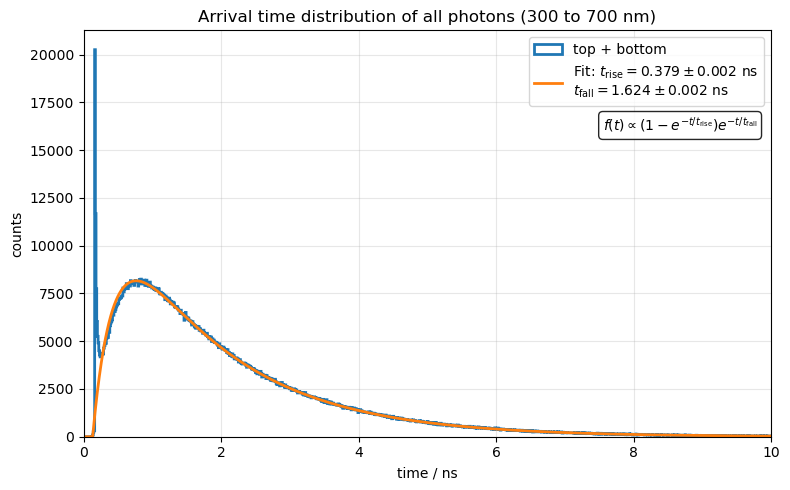

t0     = 0.1309 ± 0.0002 ns
t_rise = 0.3790 ± 0.0017 ns
t_fall = 1.6244 ± 0.0018 ns
t_peak = 0.7620 ns


In [229]:
# Fit for all data
bins = 1000
fit_range = (0, 10)

(counts_data_all, edges_data_all, centers_data_all, params_data_all, errors_data_all) = fit_dataset(
    data_arr_times_all,
    bins=bins,
    fit_range=fit_range
)

A_data_all, t0_data_all, rise_data_all, fall_data_all, bg_data_all = params_data_all

t_plot_data_all = np.linspace(
    fit_range[0],
    fit_range[1],
    3000
)

fit_data_all = scintillation_pluse_shape(
    t_plot_data_all,
    *params_data_all
)

# Plot all data and fit
plt.figure(figsize=(8, 5))

plt.hist(
    data_arr_times_all,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="top + bottom"
)

plt.plot(
    t_plot_data_all,
    fit_data_all,
    linewidth=2,
    label=(
        rf"Fit: $t_\mathrm{{rise}}="
        rf"{rise_data_all:.3f}\pm{errors_data_all[2]:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{fall_data_all:.3f}\pm{errors_data_all[3]:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

plt.text(
    0.98,
    0.79,
    fit_model_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlim(0, 10)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"t0     = {t0_data_all:.4f} "
    f"± {errors_data_all[1]:.4f} ns"
)

print(
    f"t_rise = {rise_data_all:.4f} "
    f"± {errors_data_all[2]:.4f} ns"
)

print(
    f"t_fall = {fall_data_all:.4f} "
    f"± {errors_data_all[3]:.4f} ns"
)

print(
    f"t_peak = "
    f"{scintillation_pluse_shape_maximum(t0_data_all, rise_data_all, fall_data_all):.4f} ns"
)

### Plot and Fit only Scintillation

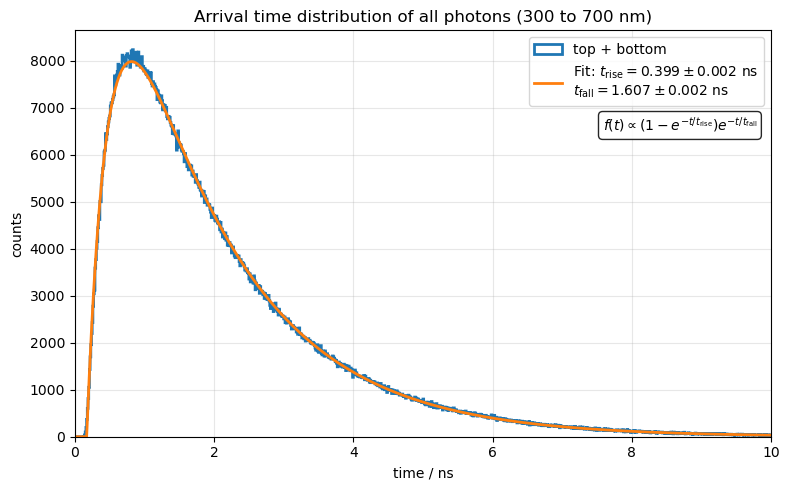

t0     = 0.1709 ± 0.0003 ns
t_rise = 0.3986 ± 0.0020 ns
t_fall = 1.6074 ± 0.0018 ns
t_peak = 0.8149 ns


In [223]:
# Fit for all data
bins = 1000
fit_range = (0, 10)

(counts_data_all, edges_data_all, centers_data_all, params_data_all, errors_data_all) = fit_dataset(
    data_arr_times_all_scintillation,
    bins=bins,
    fit_range=fit_range
)

A_data_all, t0_data_all, rise_data_all, fall_data_all, bg_data_all = params_data_all

t_plot_data_all = np.linspace(
    fit_range[0],
    fit_range[1],
    3000
)

fit_data_all = scintillation_pluse_shape(
    t_plot_data_all,
    *params_data_all
)

# Plot all data and fit
plt.figure(figsize=(8, 5))

plt.hist(
    data_arr_times_all_scintillation,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="top + bottom"
)

plt.plot(
    t_plot_data_all,
    fit_data_all,
    linewidth=2,
    label=(
        rf"Fit: $t_\mathrm{{rise}}="
        rf"{rise_data_all:.3f}\pm{errors_data_all[2]:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{fall_data_all:.3f}\pm{errors_data_all[3]:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

plt.text(
    0.98,
    0.79,
    fit_model_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlim(0, 10)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"t0     = {t0_data_all:.4f} "
    f"± {errors_data_all[1]:.4f} ns"
)

print(
    f"t_rise = {rise_data_all:.4f} "
    f"± {errors_data_all[2]:.4f} ns"
)

print(
    f"t_fall = {fall_data_all:.4f} "
    f"± {errors_data_all[3]:.4f} ns"
)

print(
    f"t_peak = "
    f"{scintillation_pluse_shape_maximum(t0_data_all, rise_data_all, fall_data_all):.4f} ns"
)

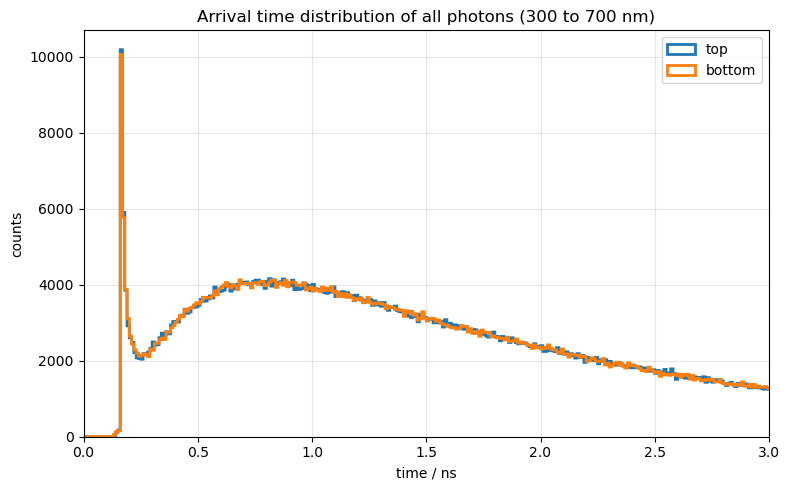

Fit top:
t0     = 0.1319 ± 0.0002 ns
t_rise = 0.3777 ± 0.0025 ns
t_fall = 1.6234 ± 0.0026 ns
t_peak = 0.7616 ns
Fit bottom:
t0     = 0.1301 ± 0.0003 ns
t_rise = 0.3828 ± 0.0025 ns
t_fall = 1.6200 ± 0.0026 ns
t_peak = 0.7636 ns


In [225]:
# Fit for top data
bins = 1000
fit_range = (0, 10)

(counts_data_top_all, edges_data_top_all, centers_data_top_all, params_data_top_all, errors_data_top_all) = fit_dataset(
    data_arr_times_all_top,
    bins=bins,
    fit_range=fit_range
)

A_data_top_all, t0_data_top_all, rise_data_top_all, fall_data_top_all, bg_data_top_all = params_data_top_all

t_plot_data_top_all = np.linspace(
    fit_range[0],
    fit_range[1],
    3000
)

fit_data_top_all = scintillation_pluse_shape(
    t_plot_data_top_all,
    *params_data_top_all
)

# Fit for bottom data
(counts_data_bottom_all, edges_data_bottom_all, centers_data_bottom_all, params_data_bottom_all, errors_data_bottom_all) = fit_dataset(
    data_arr_times_all_bottom,
    bins=bins,
    fit_range=fit_range
)

A_data_bottom_all, t0_data_bottom_all, rise_data_bottom_all, fall_data_bottom_all, bg_data_bottom_all = params_data_bottom_all

t_plot_data_bottom_all = np.linspace(
    fit_range[0],
    fit_range[1],
    3000
)

fit_data_bottom_all = scintillation_pluse_shape(
    t_plot_data_bottom_all,
    *params_data_bottom_all
)

# Plot top and bottm data and fit
plt.figure(figsize=(8, 5))

# Top hist
plt.hist(
    data_arr_times_all_top,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="top"
)

# bottom hist
plt.hist(
    data_arr_times_all_bottom,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="bottom"
)

# # top fit plot
# plt.plot(
#     t_plot_data_top_all,
#     fit_data_top_all,
#     linewidth=2,
#     label=(
#         rf"Top fit: $t_\mathrm{{rise}}="
#         rf"{rise_data_top_all:.3f}\pm{errors_data_top_all[2]:.3f}$ ns"
#         "\n"
#         rf"$t_\mathrm{{fall}}="
#         rf"{fall_data_top_all:.3f}\pm{errors_data_top_all[3]:.3f}$ ns"
#     )
# )

# # bottom fit plot
# plt.plot(
#     t_plot_data_bottom_all,
#     fit_data_bottom_all,
#     linewidth=2,
#     label=(
#         rf"Bottom fit: $t_\mathrm{{rise}}="
#         rf"{rise_data_bottom_all:.3f}\pm{errors_data_bottom_all[2]:.3f}$ ns"
#         "\n"
#         rf"$t_\mathrm{{fall}}="
#         rf"{fall_data_bottom_all:.3f}\pm{errors_data_bottom_all[3]:.3f}$ ns"
#     )
# )

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

# plt.text(
#     0.98,
#     0.63,
#     fit_model_text,
#     transform=plt.gca().transAxes,
#     fontsize=10,
#     verticalalignment="top",
#     horizontalalignment="right",
#     bbox=dict(
#         boxstyle="round",
#         facecolor="white",
#         alpha=0.85
#     )
# )

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Fit top:")

print(
    f"t0     = {t0_data_top_all:.4f} "
    f"± {errors_data_top_all[1]:.4f} ns"
)

print(
    f"t_rise = {rise_data_top_all:.4f} "
    f"± {errors_data_top_all[2]:.4f} ns"
)

print(
    f"t_fall = {fall_data_top_all:.4f} "
    f"± {errors_data_top_all[3]:.4f} ns"
)

print(
    f"t_peak = "
    f"{scintillation_pluse_shape_maximum(t0_data_top_all, rise_data_top_all, fall_data_top_all):.4f} ns"
)

print("Fit bottom:")

print(
    f"t0     = {t0_data_bottom_all:.4f} "
    f"± {errors_data_bottom_all[1]:.4f} ns"
)

print(
    f"t_rise = {rise_data_bottom_all:.4f} "
    f"± {errors_data_bottom_all[2]:.4f} ns"
)

print(
    f"t_fall = {fall_data_bottom_all:.4f} "
    f"± {errors_data_bottom_all[3]:.4f} ns"
)

print(
    f"t_peak = "
    f"{scintillation_pluse_shape_maximum(t0_data_bottom_all, rise_data_bottom_all, fall_data_bottom_all):.4f} ns"
)

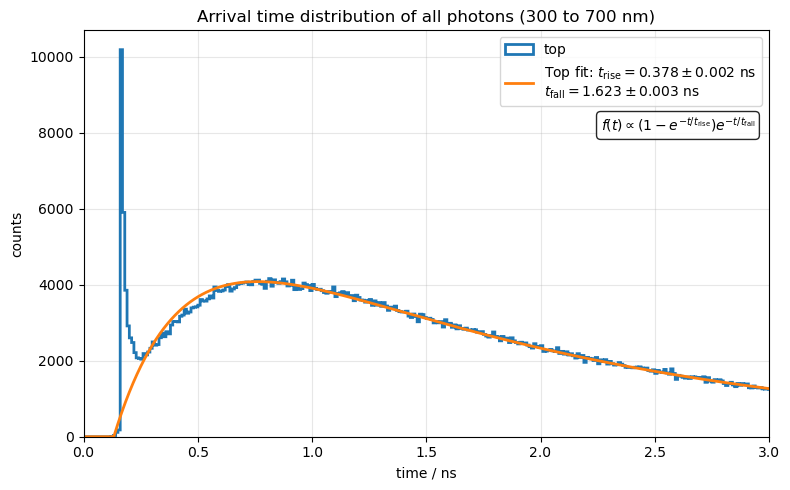

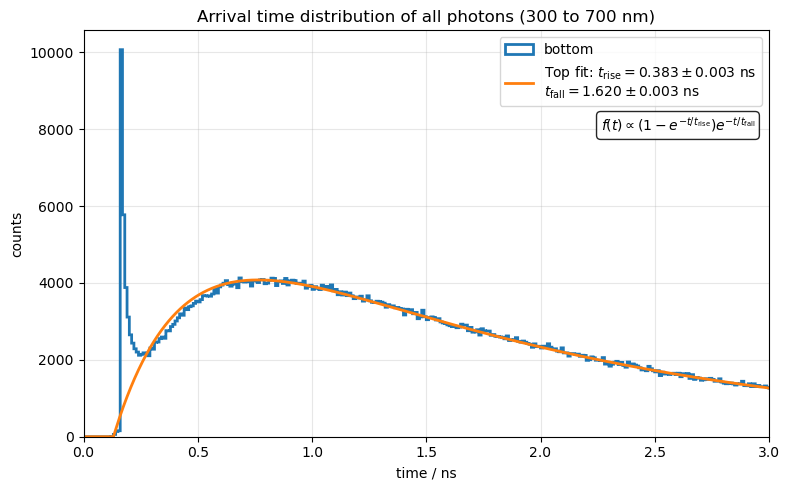

In [213]:
# Plot top
plt.figure(figsize=(8, 5))

# Top hist
plt.hist(
    data_arr_times_all_top,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="top"
)

# top fit plot
plt.plot(
    t_plot_data_top_all,
    fit_data_top_all,
    linewidth=2,
    label=(
        rf"Top fit: $t_\mathrm{{rise}}="
        rf"{rise_data_top_all:.3f}\pm{errors_data_top_all[2]:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{fall_data_top_all:.3f}\pm{errors_data_top_all[3]:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

plt.text(
    0.98,
    0.79,
    fit_model_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot bottom
plt.figure(figsize=(8, 5))

# bottom hist
plt.hist(
    data_arr_times_all_bottom,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="bottom"
)

# bottom fit plot
plt.plot(
    t_plot_data_bottom_all,
    fit_data_bottom_all,
    linewidth=2,
    label=(
        rf"Top fit: $t_\mathrm{{rise}}="
        rf"{rise_data_bottom_all:.3f}\pm{errors_data_bottom_all[2]:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{fall_data_bottom_all:.3f}\pm{errors_data_bottom_all[3]:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

plt.text(
    0.98,
    0.79,
    fit_model_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Fit pro einzelene Events

Fit an jedem Scinitllation Process

In [178]:
def fit_single_event(times, bins, fit_range):

    (
        counts_single_event,
        edges_single_event,
        centers_single_event,
        params_single_event,
        errors_single_event
    ) = fit_dataset(
        times,
        bins=bins,
        fit_range=fit_range
    )

    return params_single_event, errors_single_event

t0     = 0.1151 ± 0.0185 ns
t_rise = 0.4210 ± 0.1065 ns
t_fall = 1.4771 ± 0.1306 ns
t_peak = 0.7490 ns


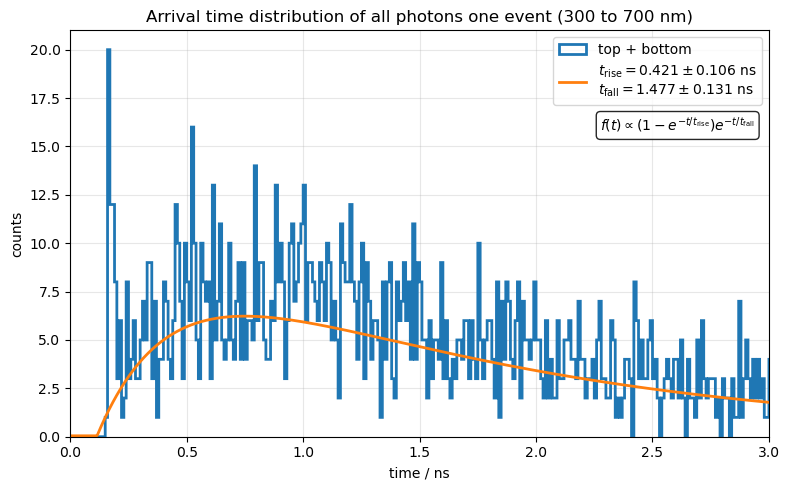

In [179]:
# Fit an plot a single event
bins = 1000
fit_range = (0, 10)

event3 = data_events[12]
event3_data_arr_times_all = event3["TimeSinceZero"]

fit_params_single_event, fit_errors_single_event = fit_single_event(
    event3_data_arr_times_all,
    bins,
    fit_range
)

A_single, t0_single, rise_single, fall_single, bg_single = (
    fit_params_single_event
)

A_err, t0_err, rise_err, fall_err, bg_err = (
    fit_errors_single_event
)

print(
    f"t0     = {t0_single:.4f} "
    f"± {t0_err:.4f} ns"
)

print(
    f"t_rise = {rise_single:.4f} "
    f"± {rise_err:.4f} ns"
)

print(
    f"t_fall = {fall_single:.4f} "
    f"± {fall_err:.4f} ns"
)

t_plot_single_event = np.linspace(
    fit_range[0],
    fit_range[1],
    3000
)

t_peak_single = scintillation_pluse_shape_maximum(
    t0_single,
    rise_single,
    fall_single
)

print(f"t_peak = {t_peak_single:.4f} ns")

fit_data_single_event = scintillation_pluse_shape(
    t_plot_single_event,
    *fit_params_single_event
)

# Plot all data and fit
plt.figure(figsize=(8, 5))

plt.hist(
    event3_data_arr_times_all,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="top + bottom"
)

plt.plot(
    t_plot_single_event,
    fit_data_single_event,
    linewidth=2,
    label=(
        rf"$t_\mathrm{{rise}}="
        rf"{rise_single:.3f}\pm{rise_err:.3f}$ ns"
        "\n"
        rf"$t_\mathrm{{fall}}="
        rf"{fall_single:.3f}\pm{fall_err:.3f}$ ns"
    )
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons one event (300 to 700 nm)")

plt.text(
    0.98,
    0.79,
    fit_model_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85
    )
)

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Fits for each event

In [180]:
event_fits = []

bins = 200
fit_range = (0, 10)

for event_id, event_data in data_events.items():

    # nur Scintillation-Photonen dieses Events
    event_scint = event_data[
        event_data["Process"] == "Scintillation"
    ]

    times = (
        event_scint["TimeSinceZero"]
        .dropna()
        .to_numpy()
    )

    # Events mit zu wenigen Photonen überspringen
    if len(times) < 20:
        continue

    try:
        # Fit durchführen
        params, errors = fit_single_event(
            times,
            bins,
            fit_range
        )

        A, t0, tau_rise, tau_fall, background = params

        (
            A_err,
            t0_err,
            tau_rise_err,
            tau_fall_err,
            background_err
        ) = errors

        # Peak-Zeit berechnen
        t_peak = scintillation_pluse_shape_maximum(
            t0,
            tau_rise,
            tau_fall
        )

        # Ergebnis speichern
        event_fits.append({
            "EventID": event_id,
            "NPhotons": len(times),

            "A": A,
            "A_error": A_err,

            "t0": t0,
            "t0_error": t0_err,

            "tau_rise": tau_rise,
            "tau_rise_error": tau_rise_err,

            "tau_fall": tau_fall,
            "tau_fall_error": tau_fall_err,

            "background": background,
            "background_error": background_err,

            "t_peak": t_peak
        })

    except RuntimeError:
        print(f"Fit failed for Event {event_id}")

In [181]:
event_fits = pd.DataFrame(event_fits)

print(event_fits.head())
print(f"Successful fits: {len(event_fits)}")

   EventID  NPhotons           A    A_error        t0  t0_error  tau_rise  \
0        0      2489  117.714534  12.821249  0.163156  0.007233  0.587797   
1        1      2211   93.766308   8.556305  0.174857  0.004755  0.454563   
2        2      1617   78.222521  11.427136  0.160851  0.011859  0.572001   
3        3      1629   77.540048  10.070556  0.209635  0.010967  0.477927   
4        4      1588   64.583133   6.944490  0.167212  0.006906  0.430577   

   tau_rise_error  tau_fall  tau_fall_error  background  background_error  \
0        0.102089  1.421601        0.076083    0.014955          0.167362   
1        0.072410  1.440983        0.074737    0.104393          0.159125   
2        0.134613  1.345326        0.093817    0.004767          0.147746   
3        0.105836  1.276652        0.083203    0.253793          0.141035   
4        0.084589  1.447883        0.090847    0.070921          0.153046   

     t_peak  
0  0.885681  
1  0.823939  
2  0.852713  
3  0.831191  
4  0

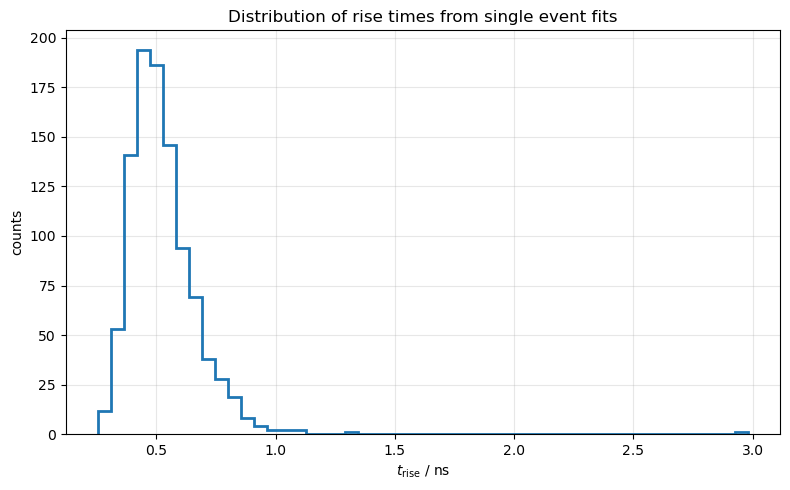

In [214]:
plt.figure(figsize=(8, 5))

plt.hist(
    event_fits["tau_rise"],
    bins=50,
    histtype="step",
    linewidth=2
)

plt.xlabel(r"$t_\mathrm{rise}$ / ns")
plt.ylabel("counts")
plt.title("Distribution of rise times from single event fits")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [215]:
sigma_rise = event_fits["tau_rise"].std(ddof=1)
mean_rise = event_fits["tau_rise"].mean()

print(f"Mean rise time   = {mean_rise:.4f} ns")
print(f"Rise-time spread = {sigma_rise:.4f} ns")
print(f"Sigma            = {sigma_rise * 1000:.2f} ps")

Mean rise time   = 0.5269 ns
Rise-time spread = 0.1525 ns
Sigma            = 152.46 ps


In [216]:
tau_rise_values = (
    event_fits["tau_rise"]
    .dropna()
    .to_numpy()
)

mean_tau_rise = np.mean(tau_rise_values)
jitter_tau_rise = np.std(
    tau_rise_values,
    ddof=1
)

print(
    f"Mean tau_rise = "
    f"{mean_tau_rise:.4f} ns"
)

print(
    f"tau_rise jitter = "
    f"{jitter_tau_rise:.4f} ns"
)

print(
    f"tau_rise jitter = "
    f"{jitter_tau_rise * 1000:.2f} ps"
)

Mean tau_rise = 0.5269 ns
tau_rise jitter = 0.1525 ns
tau_rise jitter = 152.46 ps


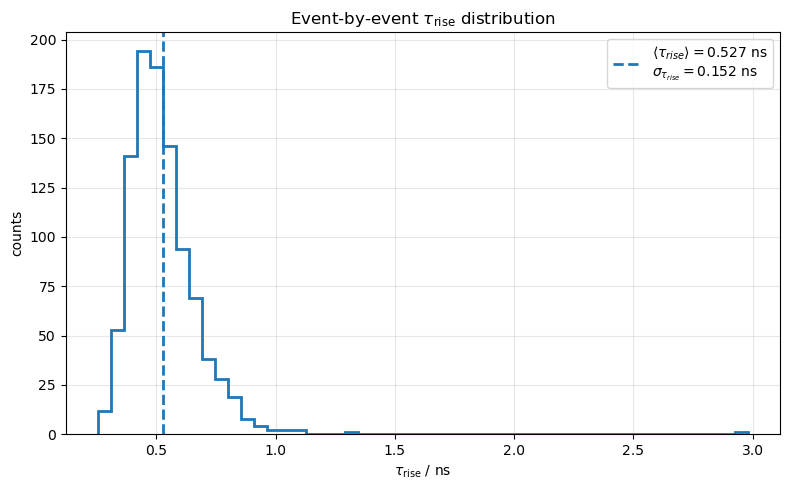

In [217]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau_rise_values,
    bins=50,
    histtype="step",
    linewidth=2
)

plt.axvline(
    mean_tau_rise,
    linestyle="--",
    linewidth=2,
    label=(
        rf"$\langle\tau_{{rise}}\rangle"
        rf"={mean_tau_rise:.3f}$ ns"
        "\n"
        rf"$\sigma_{{\tau_{{rise}}}}"
        rf"={jitter_tau_rise:.3f}$ ns"
    )
)

plt.xlabel(r"$\tau_\mathrm{rise}$ / ns")
plt.ylabel("counts")
plt.title(r"Event-by-event $\tau_\mathrm{rise}$ distribution")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot and Fit for each Event top and bottom sep: Diff.

In [235]:
# Time at which the photon count crosses the threshold
photon_threshold = 250
threshold_times = []

for event_id, event_data in data.groupby("EventID"):
    result = {"EventID": event_id}

    for hit_position in ("top", "bottom"):
        hit_times = (
            event_data.loc[
                event_data["Hit"].astype(str).str.lower() == hit_position,
                "TimeSinceZero"
            ]
            .dropna()
            .sort_values()
            .to_numpy()
        )

        if len(hit_times) >= photon_threshold:
            # The N-th arrival is the threshold-crossing time.
            threshold_index = photon_threshold - 1
            result[f"{hit_position}_threshold_time"] = hit_times[threshold_index]
        else:
            result[f"{hit_position}_threshold_time"] = np.nan

    threshold_times.append(result)

threshold_times = pd.DataFrame(threshold_times)

print(f"Photon threshold: {photon_threshold}")
print(threshold_times.head())
print("\nNumber of events crossing the threshold:")
print(threshold_times.notna().sum(numeric_only=True))

Photon threshold: 250
   EventID  top_threshold_time  bottom_threshold_time
0        0            0.786827               0.787728
1        1            0.800075               0.824260
2        2            0.973551               0.975500
3        3            0.955757               0.936196
4        4            1.005230               0.945713

Number of events crossing the threshold:
EventID                  1000
top_threshold_time       1000
bottom_threshold_time    1000
dtype: int64


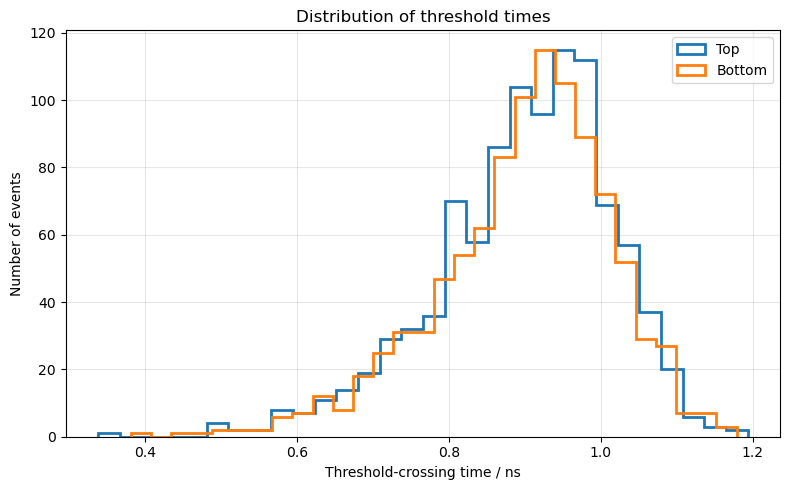

In [237]:
# Histogram of threshold-crossing times
threshold_time_columns = [
    "top_threshold_time",
    "bottom_threshold_time"
]

threshold_time_values = [
    threshold_times[column].dropna().to_numpy()
    for column in threshold_time_columns
]

plt.figure(figsize=(8, 5))

plt.hist(
    threshold_time_values[0],
    bins=30,
    histtype="step",
    linewidth=2,
    label="Top"
)

plt.hist(
    threshold_time_values[1],
    bins=30,
    histtype="step",
    linewidth=2,
    label="Bottom"
)

plt.xlabel("Threshold-crossing time / ns")
plt.ylabel("Number of events")
plt.title(f"Distribution of threshold times")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Plot for one event

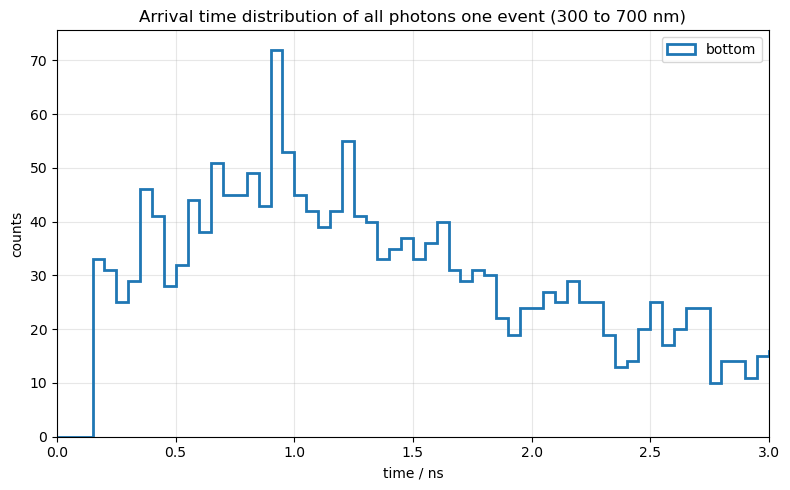

In [218]:
bins = 200
fit_range = (0,10)

# Plot for one event (top and bottom)
plt.figure(figsize=(8, 5))

# bottom hist
plt.hist(
    data_events[1]["TimeSinceZero"],
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="bottom"
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons one event (300 to 700 nm)")

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

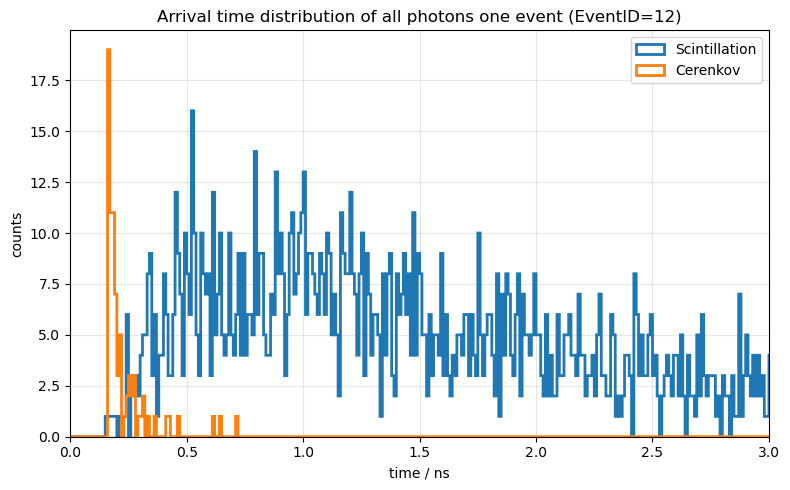

In [220]:
bins = 1000
fit_range = (0, 10)

event_id = 12
event_data = data_events[event_id]

event_scintillation = event_data[
    event_data["Process"] == "Scintillation"
]

event_cerenkov = event_data[
    event_data["Process"] == "Cerenkov"
]

plt.figure(figsize=(8, 5))

plt.hist(
    event_scintillation["TimeSinceZero"],
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Scintillation"
)

plt.hist(
    event_cerenkov["TimeSinceZero"],
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Cerenkov"
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title(f"Arrival time distribution of all photons one event (EventID={event_id})")

plt.xlim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Plot und Fit getrennt: Cerenkov und Scintillation

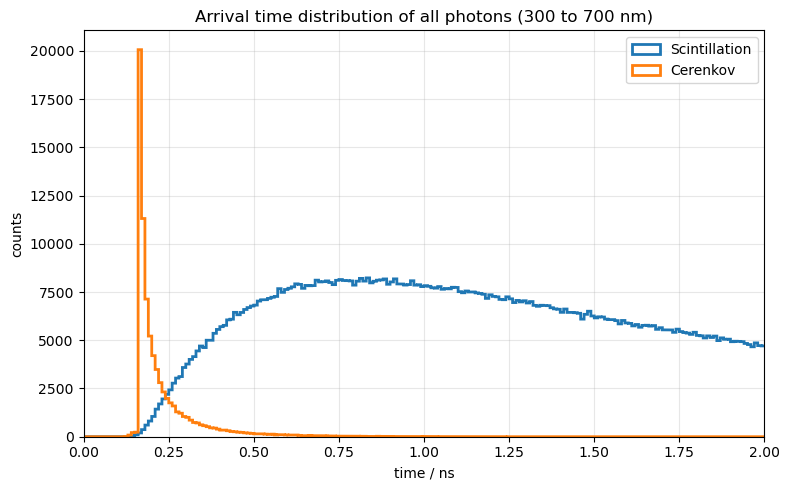

In [221]:
bins = 1000
fit_range = (0, 10)

# plot separately
plt.figure(figsize=(8, 5))

# plot scintillation
plt.hist(
    data_arr_times_all_scintillation,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Scintillation"
)

# plot cerenkov
plt.hist(
    data_arr_times_all_cerenkov,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Cerenkov"
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of all photons (300 to 700 nm)")

plt.xlim(0, 2)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Cerenkov peak = 0.1650 ns


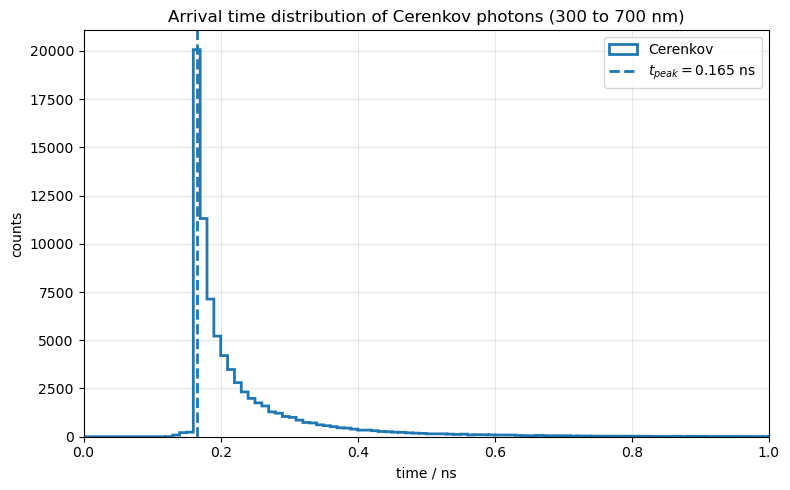

In [189]:
bins = 1000
fit_range = (0, 10)

# Histogrammdaten berechnen
counts, bin_edges = np.histogram(
    data_arr_times_all_cerenkov,
    bins=bins,
    range=fit_range
)

# Bin-Zentren
bin_centers = 0.5 * (
    bin_edges[:-1] + bin_edges[1:]
)

# Bin mit maximalen Counts
peak_index = np.argmax(counts)

# Peak-Zeit
t_peak_cerenkov = bin_centers[peak_index]

print(f"Cerenkov peak = {t_peak_cerenkov:.4f} ns")

plt.figure(figsize=(8, 5))

plt.hist(
    data_arr_times_all_cerenkov,
    bins=bins,
    range=fit_range,
    histtype="step",
    linewidth=2,
    label="Cerenkov"
)

plt.axvline(
    t_peak_cerenkov,
    linestyle="--",
    linewidth=2,
    label=rf"$t_{{peak}} = {t_peak_cerenkov:.3f}$ ns"
)

plt.xlabel("time / ns")
plt.ylabel("counts")
plt.title("Arrival time distribution of Cerenkov photons (300 to 700 nm)")

plt.xlim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Spektrum der Photonen

Data wavelength peak = 368.855 nm


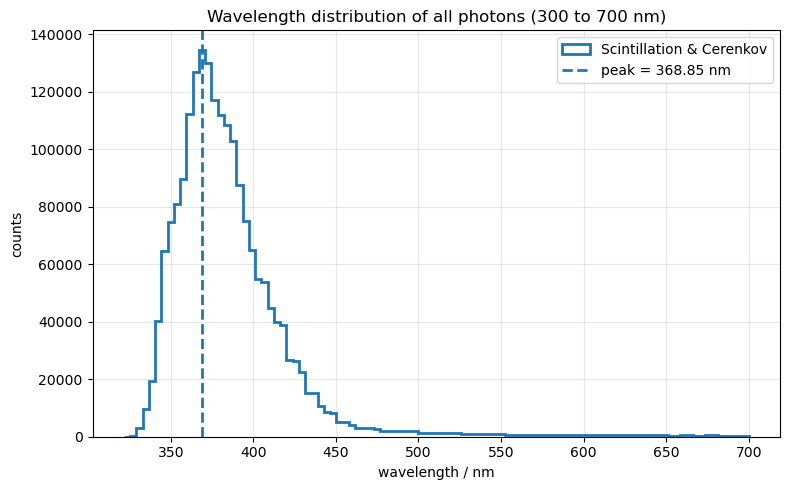

In [230]:
# plot both

bins = 100

counts_data_all, edges_data_all = np.histogram(
    data_wavelength_all,
    bins=bins
)

# Bin-Zentren
centers_data_all = 0.5 * (
    edges_data_all[:-1] + edges_data_all[1:]
)

# Maximum
peak_index_data_all = np.argmax(counts_data_all)

wavelength_peak_data_all = centers_data_all[peak_index_data_all]

print(
    f"Data wavelength peak = "
    f"{wavelength_peak_data_all:.3f} nm"
)

# plot
plt.figure(figsize=(8, 5))

plt.hist(
    data_wavelength_all,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Scintillation & Cerenkov"
)

# Peak
plt.axvline(
    wavelength_peak_data_all,
    linestyle="--",
    linewidth=2,
    label=(
        rf"peak = "
        rf"{wavelength_peak_data_all:.2f} nm"
    )
)

plt.xlabel("wavelength / nm")
plt.ylabel("counts")
plt.title("Wavelength distribution of all photons (300 to 700 nm)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

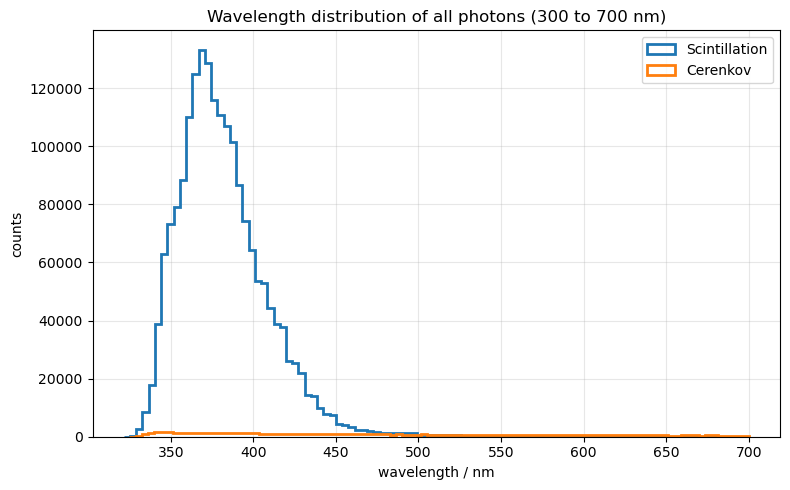

In [191]:
# plot separately

bins = 100

# plot
plt.figure(figsize=(8, 5))

plt.hist(
    data_wavelength_scintillation,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Scintillation"
)

plt.hist(
    data_wavelength_cerenkov,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Cerenkov"
)

plt.xlabel("wavelength / nm")
plt.ylabel("counts")
plt.title("Wavelength distribution of all photons (300 to 700 nm)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Scintillation wavelength peak = 368.77 nm


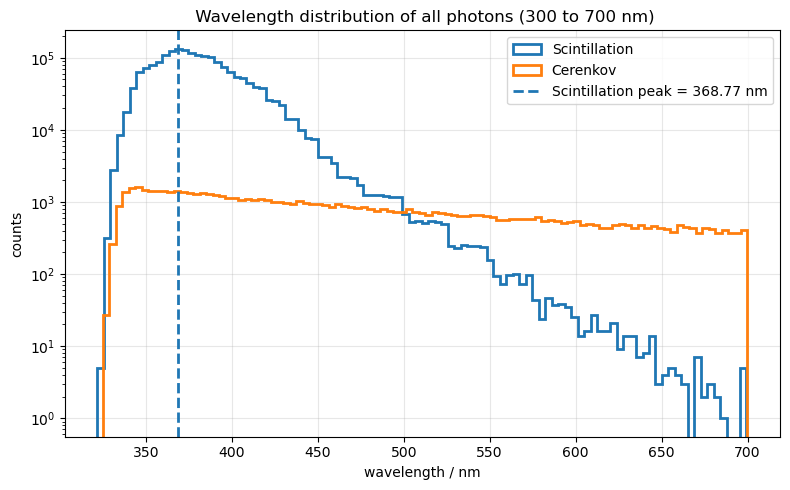

In [192]:
# plot separately

bins = 100


# Histogramm nur für Scintillation
counts_data_all_scint, edges_data_all_scint = np.histogram(
    data_wavelength_scintillation,
    bins=bins
)

# Bin-Zentren
centers_data_all_scint = 0.5 * (
    edges_data_all_scint[:-1] + edges_data_all_scint[1:]
)

# Maximum bestimmen
peak_index_data_all_scint = np.argmax(counts_data_all_scint)

wavelength_peak_data_all_scint = centers_data_all_scint[peak_index_data_all_scint]

print(
    f"Scintillation wavelength peak = "
    f"{wavelength_peak_data_all_scint:.2f} nm"
)

# plot
plt.figure(figsize=(8, 5))

plt.hist(
    data_wavelength_scintillation,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Scintillation"
)

plt.hist(
    data_wavelength_cerenkov,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="Cerenkov"
)

# Peak der Scintillation
plt.axvline(
    wavelength_peak_data_all_scint,
    linestyle="--",
    linewidth=2,
    label=(
        rf"Scintillation peak = "
        rf"{wavelength_peak_data_all_scint:.2f} nm"
    )
)

plt.xlabel("wavelength / nm")
plt.ylabel("counts")
plt.title(" Wavelength distribution of all photons (300 to 700 nm)")
plt.yscale("log")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [193]:
# Counts of all Cerenkov events
counts_cerenkov = len(data_wavelength_cerenkov)
print(f"All cerenkov counts ({counts_events} events): {counts_cerenkov}")

# Mean counts per event: 500 events
mean_cerenkov_per_event = counts_cerenkov / counts_events
print(f"Mean counts cerenkov per Event: {mean_cerenkov_per_event:.2f}")

All cerenkov counts (1000 events): 77556
Mean counts cerenkov per Event: 77.56


### Cerenkov Light

In [194]:
theta_deg = np.degrees(theta)
print(theta_deg)

50.734752086120544


# Plots only Cerenkov

Cerenkov wavelength peak = 342.66 nm


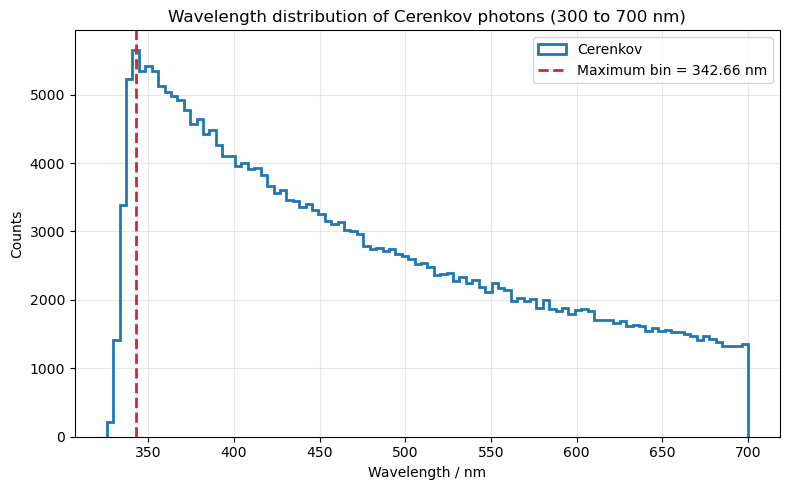

In [195]:
bins = 100

counts_cerenkov, bin_edges_cerenkov = np.histogram(
    wavelengths_cerenkov,
    bins=bins
)

max_bin_index = np.argmax(counts_cerenkov)
wavelength_peak_cerenkov = (
    bin_edges_cerenkov[max_bin_index]
    + bin_edges_cerenkov[max_bin_index + 1]
) / 2

print(f"Cerenkov wavelength peak = {wavelength_peak_cerenkov:.2f} nm")

plt.figure(figsize=(8, 5))

plt.hist(
    wavelengths_cerenkov,
    bins=bins,
    histtype="step",
    linewidth=2,
    color="tab:blue",
    label="Cerenkov"
)

plt.axvline(
    wavelength_peak_cerenkov,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=rf"Maximum bin = {wavelength_peak_cerenkov:.2f} nm"
)

plt.xlabel("Wavelength / nm")
plt.ylabel("Counts")
plt.title("Wavelength distribution of Cerenkov photons (300 to 700 nm)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

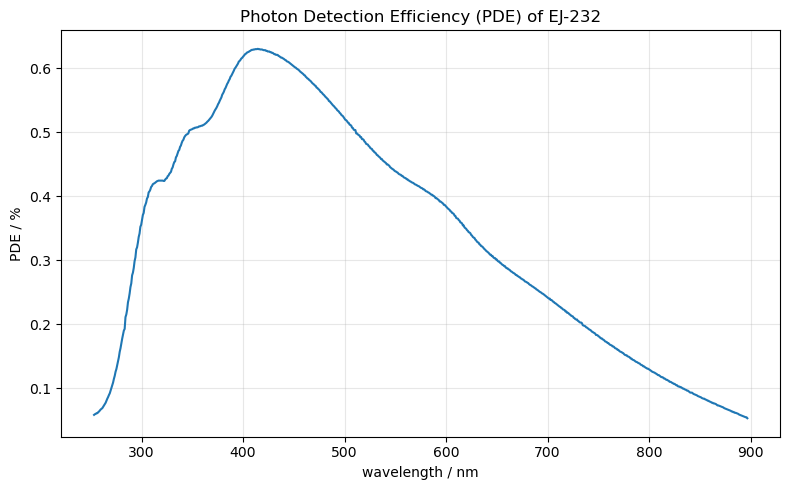

In [239]:
import numpy as np
import matplotlib.pyplot as plt

pde_data = np.loadtxt("ej232PDE.txt", skiprows=1)
x = pde_data[:, 0]
y = pde_data[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=1.5)
plt.xlabel("wavelength / nm")
plt.ylabel("PDE / %")
plt.title("Photon Detection Efficiency (PDE) of EJ-232")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

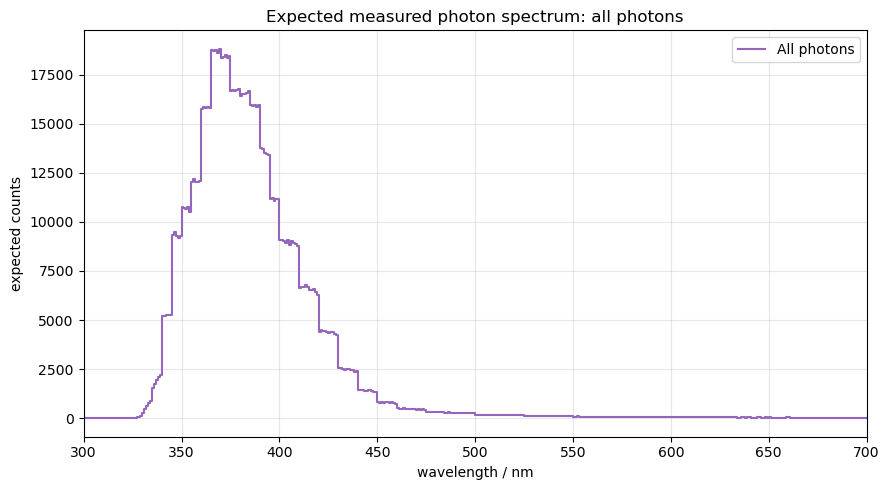

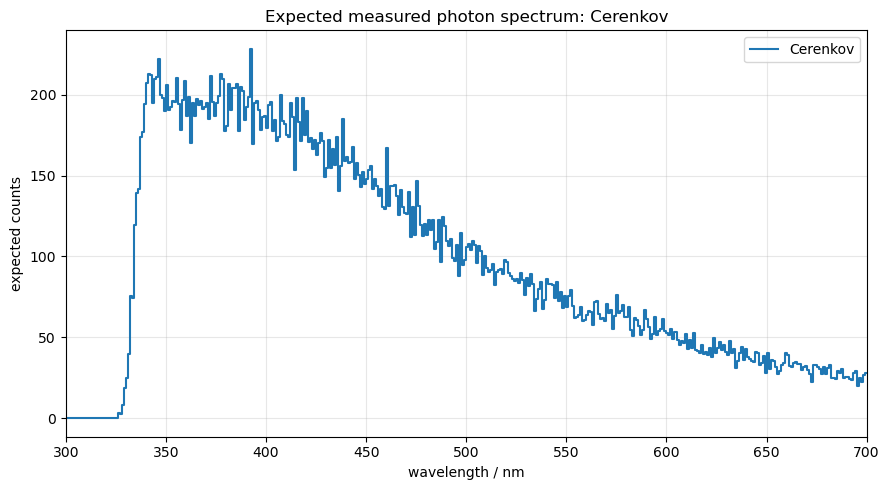

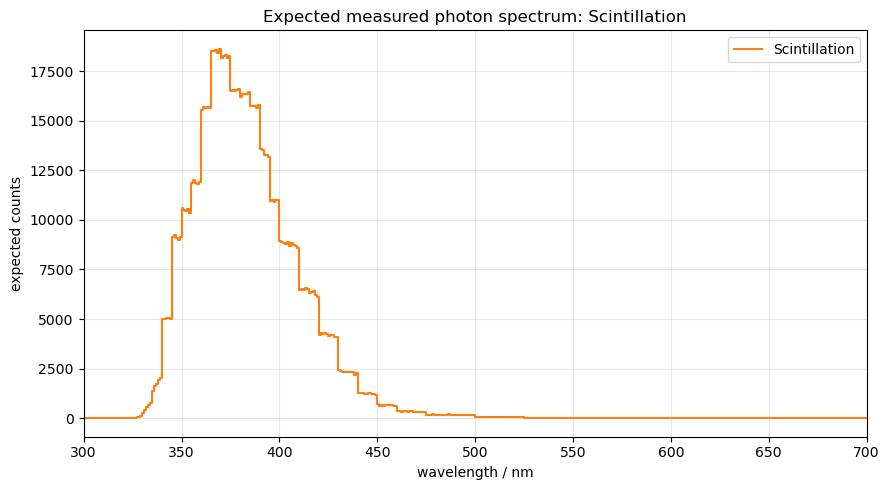

In [197]:
# Wavelength range and histogram bins
wavelength_range = (300, 700)
bins = np.arange(300, 701, 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Wavelength data for each photon group
wavelengths_scintillation = (
    data_all_scintillation["WavelengthNM"]
    .dropna()
    .to_numpy()
)

wavelengths_cerenkov = (
    data_all_cerenkov["WavelengthNM"]
    .dropna()
    .to_numpy()
)

wavelengths_all = np.concatenate(
    [wavelengths_scintillation, wavelengths_cerenkov]
)

pde_at_bins = np.interp(bin_centers, x, y)


def plot_expected_spectrum(wavelengths, title, label, color):
    counts, _ = np.histogram(wavelengths, bins=bins)
    expected_counts = counts * pde_at_bins

    plt.figure(figsize=(9, 5))
    plt.step(
        bin_centers,
        expected_counts,
        where="mid",
        linewidth=1.5,
        color=color,
        label=label
    )
    plt.xlabel("wavelength / nm")
    plt.ylabel("expected counts")
    plt.title(title)
    plt.xlim(*wavelength_range)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_expected_spectrum(
    wavelengths_all,
    "Expected measured photon spectrum: all photons",
    "All photons",
    "tab:purple"
)

plot_expected_spectrum(
    wavelengths_cerenkov,
    "Expected measured photon spectrum: Cerenkov",
    "Cerenkov",
    "tab:blue"
)

plot_expected_spectrum(
    wavelengths_scintillation,
    "Expected measured photon spectrum: Scintillation",
    "Scintillation",
    "tab:orange"
)

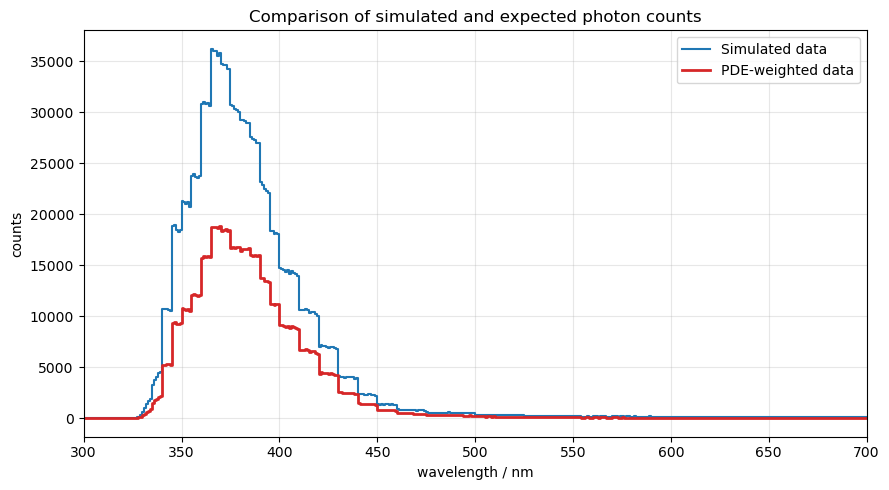

In [198]:
# Comparison: simulated photons and expected detected counts

counts_simulated, _ = np.histogram(
    wavelengths_all,
    bins=bins
)

expected_counts = counts_simulated * pde_at_bins

plt.figure(figsize=(9, 5))

plt.step(
    bin_centers,
    counts_simulated,
    where="mid",
    linewidth=1.5,
    color="tab:blue",
    label="Simulated data"
)

plt.step(
    bin_centers,
    expected_counts,
    where="mid",
    linewidth=2,
    color="tab:red",
    label="PDE-weighted data"
)

plt.xlabel("wavelength / nm")
plt.ylabel("counts")
plt.title("Comparison of simulated and expected photon counts")
plt.xlim(*wavelength_range)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

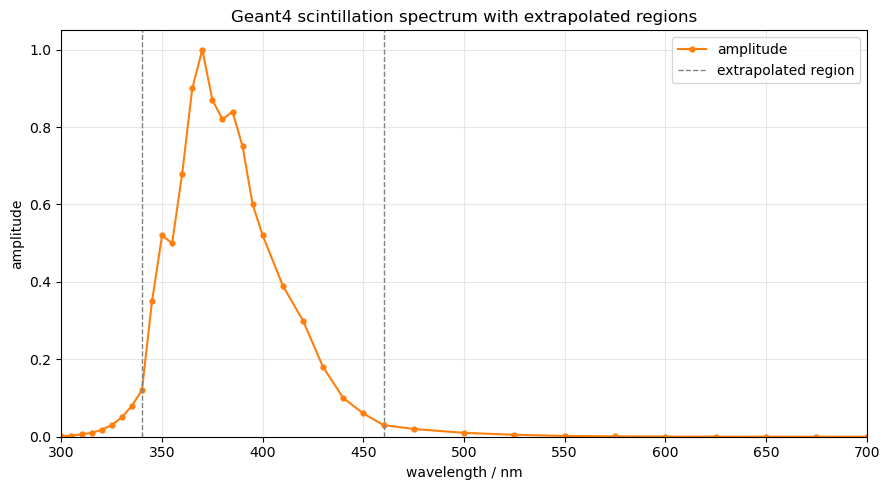

In [199]:
# Geant4 scintillation amplitude spectrum
photon_energy_eV = np.array([
    1.7712, 1.8368, 1.9074, 1.9837, 2.0664, 2.1562,
    2.2543, 2.3616, 2.4797, 2.6102, 2.6953, 2.7552,
    2.8178, 2.8834, 2.9520, 3.0240, 3.0996, 3.1388,
    3.1791, 3.2204, 3.2627, 3.3062, 3.3509, 3.3968,
    3.4440, 3.4925, 3.5424, 3.5937, 3.6466, 3.7010,
    3.7571, 3.8149, 3.8745, 3.9360, 3.9995, 4.0651,
    4.1328
])

scintillation_amplitude = np.array([
    0.00002, 0.00003, 0.0001, 0.0002, 0.0004, 0.001,
    0.002, 0.005, 0.01, 0.02, 0.03, 0.06, 0.10, 0.18,
    0.30, 0.39, 0.52, 0.60, 0.75, 0.84, 0.82, 0.87,
    1.00, 0.90, 0.68, 0.50, 0.52, 0.35, 0.12, 0.08,
    0.05, 0.03, 0.018, 0.010, 0.006, 0.003, 0.0015
])

# E = hc / lambda, with hc = 1239.841984 eV nm
scintillation_wavelength_nm = 1239.841984 / photon_energy_eV
sort_index = np.argsort(scintillation_wavelength_nm)
scintillation_wavelength_nm = scintillation_wavelength_nm[sort_index]
scintillation_amplitude = scintillation_amplitude[sort_index]

plt.figure(figsize=(9, 5))
plt.plot(
    scintillation_wavelength_nm,
    scintillation_amplitude,
    marker="o",
    markersize=3.5,
    linewidth=1.5,
    color="tab:orange",
    label="amplitude"
)

# The spectrum outside 340-460 nm is extrapolated.
plt.axvline(340, color="gray", linestyle="--", linewidth=1, label="extrapolated region")
plt.axvline(460, color="gray", linestyle="--", linewidth=1, label="_nolegend_")

plt.xlabel("wavelength / nm")
plt.ylabel("amplitude")
plt.title("Geant4 scintillation spectrum with extrapolated regions")
plt.xlim(300, 700)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

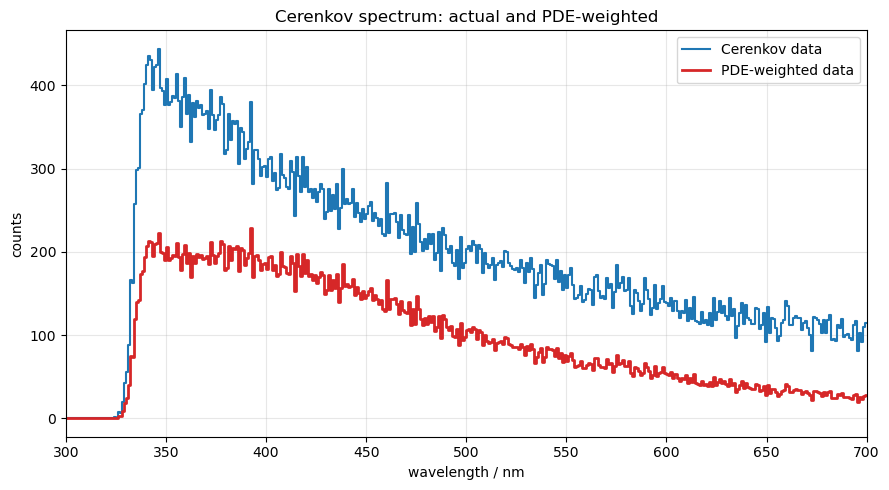

In [203]:
# Cerenkov spectrum: simulated data and PDE-weighted data
wavelength_range_cerenkov = (300, 700)
bins_cerenkov = np.arange(300, 701, 1)
bin_centers_cerenkov = 0.5 * (
    bins_cerenkov[:-1] + bins_cerenkov[1:]
)

wavelengths_cerenkov = (
    data_all_cerenkov["WavelengthNM"]
    .dropna()
    .to_numpy()
)

# Actual simulated Cerenkov photon counts
counts_cerenkov, _ = np.histogram(
    wavelengths_cerenkov,
    bins=bins_cerenkov
)

# Apply the PDE only to the Cerenkov wavelength data
pde_cerenkov = np.interp(
    bin_centers_cerenkov,
    x,
    y
)
expected_cerenkov_counts = counts_cerenkov * pde_cerenkov

plt.figure(figsize=(9, 5))

plt.step(
    bin_centers_cerenkov,
    counts_cerenkov,
    where="mid",
    linewidth=1.5,
    color="tab:blue",
    label="Cerenkov data"
)

plt.step(
    bin_centers_cerenkov,
    expected_cerenkov_counts,
    where="mid",
    linewidth=2,
    color="tab:red",
    label="PDE-weighted data"
)

plt.xlabel("wavelength / nm")
plt.ylabel("counts")
plt.title("Cerenkov spectrum: actual and PDE-weighted")
plt.xlim(*wavelength_range_cerenkov)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()